# Assignment 2 2AMM10 2023-2024

## Group: Group 17
### Member 1: Elena Terzieva
### Member 2: Konstantin Georgiev


We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [1]:
!pip install torch
!pip install rdkit --quiet
!pip install torch_geometric torchaudio torchvision --quiet
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html --quiet
!python -m pip install git+https://github.com/MolecularAI/pysmilesutils.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [2]:
import pickle
import numpy as np

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.rdmolfiles import MolToSmiles
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt
import random

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataloader import default_collate
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pysmilesutils.tokenize import SMILESAtomTokenizer
from pysmilesutils.augment import SMILESAugmenter
from pysmilesutils.datautils import BucketBatchSampler
# from pysmilesutils.tokenize  import SMILESCollater
import torch.nn.functional as F

In [3]:
# contents inside folder
!ls

sample_data


In [4]:
import os
import shutil

# Clone the repository
if os.path.exists('./DeepLearningA2'):
    shutil.rmtree('./DeepLearningA2')  # Remove if exists

print("Cloning repository...")
!git clone https://github.com/KonstantinGeorgiev0/DeepLearningA2.git

# Create the target directory
!mkdir -p ./ass2_data

# Copy files from the cloned repo
print("Copying files...")
!cp -v ./DeepLearningA2/ass2/ass2_data/*.pkl ./ass2_data/ 2>/dev/null || echo "No .pkl files found"
!cp -v ./DeepLearningA2/ass2/ass2_data/*.npz ./ass2_data/ 2>/dev/null || echo "No .npz files found"

# List what we have
print("\nFiles in ass2_data:")
!ls -la ./ass2_data/

# Check the source directory structure
print("\nSource directory structure:")
!find ./DeepLearningA2 -name "*.pkl" -o -name "*.npz" | head -10

Cloning repository...
Cloning into 'DeepLearningA2'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 32 (delta 0), reused 2 (delta 0), pack-reused 28 (from 1)
Receiving objects: 100% (32/32), 60.63 MiB | 16.38 MiB/s, done.
Copying files...
'./DeepLearningA2/ass2/ass2_data/pos_data.pkl' -> './ass2_data/pos_data.pkl'
'./DeepLearningA2/ass2/ass2_data/smiles.pkl' -> './ass2_data/smiles.pkl'
'./DeepLearningA2/ass2/ass2_data/type_data.pkl' -> './ass2_data/type_data.pkl'
'./DeepLearningA2/ass2/ass2_data/data_split.npz' -> './ass2_data/data_split.npz'
'./DeepLearningA2/ass2/ass2_data/formation_energy.npz' -> './ass2_data/formation_energy.npz'

Files in ass2_data:
total 58248
drwxr-xr-x 2 root root     4096 Jun 19 18:44 .
drwxr-xr-x 1 root root     4096 Jun 19 18:44 ..
-rw-r--r-- 1 root root  1032616 Jun 19 18:44 data_split.npz
-rw-r--r-- 1 root root   516790 Jun 19 18:44 formation_energy.npz
-rw-r

In [5]:
with open(f'./ass2_data/pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open(f'./ass2_data/type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open(f'./ass2_data/smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load(f'./ass2_data/data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load(f'./ass2_data/formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [6]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [7]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


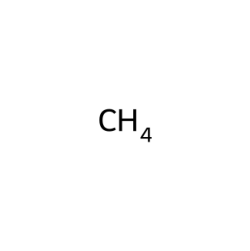

In [8]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  N  │  7   │    -0.216│     1.305│    -0.032
  C  │  6   │    -0.000│    -0.018│     0.232
  O  │  8   │     0.918│    -0.471│     0.865
  O  │  8   │    -1.029│    -0.750│    -0.303
  C  │  6   │    -0.946│    -2.155│    -0.132
  C  │  6   │    -1.243│    -2.701│     1.243
  C  │  6   │    -2.280│    -2.804│     0.158
  C  │  6   │    -0.000│    -2.814│    -0.990
  C  │  6   │     0.771│    -3.374│    -1.722
  H  │  1   │     0.564│     1.918│     0.129
  H  │  1   │    -0.865│     1.551│    -0.760
  H  │  1   │    -0.707│    -3.592│     1.548
  H  │  1   │    -1.391│    -1.964│     2.023
  H  │  1   │    -3.129│    -2.131│     0.200
  H  │  1   │    -2.472│    -3.767│    -0.299
  H  │  1   │     1.468│    -3.863│    -2.356


SMILE: C#CC1(OC(N)=O)CC1


Formation Energy: -70.202
Formation Energy (normalized): 0.58017


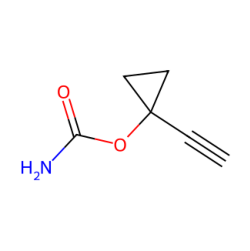

In [9]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

### SMILES Model

#### Tokenizer:

#### Augmenter:
The augmenter generates randomised versions of a SMILES string that are still chemically equivalent to the original molecule.

This gives the model different syntactic views for the same molecule.

Teaches the model to learn molecule properties, not string quirks. Reduces overfitting.

In [10]:
# Tokenizer & augmenter
# fit the vocabulary
train_smiles = [smiles_data[i] for i in train_idxes]
tokenizer    = SMILESAtomTokenizer(smiles=train_smiles) # learns vocab
augmenter    = SMILESAugmenter(restricted=True)

# direct dict lookup for special tokens
PAD_ID = tokenizer.vocabulary[' ']   # space is the reserved pad symbol
BOS_ID = tokenizer.vocabulary['^']   # begin-of-sequence
EOS_ID = tokenizer.vocabulary['&']   # end-of-sequence
UNK_ID = tokenizer.vocabulary['?']   # unknown / fallback


In [11]:
print(tokenizer("c1ccccc1N"))
print(PAD_ID, BOS_ID, EOS_ID)

[tensor([ 1, 17,  8, 17, 17, 17, 17, 17,  8, 10,  2])]
0 1 2


#### Collater
The collater is a function that receives a list of individual samples from the dataset and assembles them into a batch.

It pads token ID sequences to the length of the longest molecule in the batch.

Computes a lens tensor so the GRU can ignore padded positions.

Stacks the energies into a target vector y.

In [12]:
# --- collater --- #
class SMILESCollater():
    def __init__(self, tokenizer, pad_id):
        self.pad_id = pad_id

    def __call__(self, batch):
        seqs, energies = zip(*batch)
        # pad sequences
        padded   = pad_sequence(
            [torch.tensor(s) for s in seqs],
            batch_first=True,
            padding_value=self.pad_id
            )
        lens     = torch.tensor(
            [len(s) for s in seqs],
            dtype=torch.long
            )
        energies = torch.tensor(
            energies,
            dtype=torch.float32
            )
        return padded, lens, energies


In [13]:
tokenizer.batch_first = True
tokenizer.adaptive_padding = False

# collater = SMILESCollater(tokenizer, augmenter)
# change to new collater with pad_id not aug
collater = SMILESCollater(tokenizer, PAD_ID)

In [14]:
class SMILESDataset(Dataset):
    def __init__(self, idxs, smiles, y, train=True, augmenter=None):
        self.idxs, self.smiles, self.y = idxs, smiles, y
        self.train, self.aug = train, augmenter

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, k):
        j     = self.idxs[k]
        s     = self.smiles[j]
        if self.train and self.aug is not None:
            s = self.aug(s)[0]              # randomise SMILES

        # Tokenize and flatten the list of tensors into a list of integers
        token_ids_nested_tensors = tokenizer(s)
        token_ids = []
        for t in token_ids_nested_tensors:
            if isinstance(t, torch.Tensor):
                # Assuming the tensor contains integer token IDs
                token_ids.extend(t.tolist()) # Use tolist() to convert tensor to list and extend

        # Manually add BOS and EOS
        token_ids = [BOS_ID] + token_ids + [EOS_ID]

        return token_ids, float(self.y[j])          # list of token ids, one float

# Data loaders
train_ds = SMILESDataset(
    train_idxes, smiles_data, fe, train=True, augmenter=augmenter
    )
val_ds   = SMILESDataset(
    test_idxes,  smiles_data, fe, train=False, augmenter=None
    )

# bucket sampler
bucket_sampler = BucketBatchSampler(
    train_ds,
    batch_size=256,
    bucket_size=1024,
    # drop_last=False,
)

train_dl = DataLoader(
    train_ds, batch_sampler=bucket_sampler,
    collate_fn=SMILESCollater(tokenizer, PAD_ID), num_workers=2
    )
val_dl   = DataLoader(
    val_ds, batch_size=256, shuffle=False,
    collate_fn=SMILESCollater(tokenizer, PAD_ID), num_workers=2
    )


In [15]:
x, lens, y = next(iter(train_dl))
print(x.shape)     # e.g. torch.Size([256, 64])
print(lens[:5])    # lengths should be ≤ x.shape[1]
print(y[:5])       # tensor of normalised energies
print(lens.min(), lens.max())


torch.Size([256, 57])
tensor([40, 29, 33, 25, 32])
tensor([-1.1924, -1.7731,  0.0321,  0.1891,  0.1411])
tensor(10) tensor(57)


In [16]:
# VERSION 1
class SmilesGRU(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_layers=2, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(
            len(tokenizer.vocabulary),
            d_model,
            padding_idx=PAD_ID
            )
        self.gru   = nn.GRU(
            d_model, d_model, n_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout
            )
        self.lin_pool = nn.Linear(
            2*d_model, d_model
            )           # compress bi-dir
        self.head = nn.Sequential(
            nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model//2), nn.SiLU(),
            nn.Linear(d_model//2, 1)
        )
        for m in self.modules():                                # Xavier init
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, x, lens):
        emb = self.embed(x)                                     # [B,L,E]
        packed = pack_padded_sequence(emb, lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        h, _ = pad_packed_sequence(packed_out, batch_first=True)  # [B,L,2E]
        mask = (x != PAD_ID).unsqueeze(-1)
        alpha = mask.float() / mask.sum(1, keepdim=True)        # simple mean-attention
        pooled = (h * alpha).sum(1)                             # [B,2E]
        return self.head(self.lin_pool(pooled)).squeeze(-1)


In [17]:
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model   = SmilesGRU(len(tokenizer.vocabulary)).to(device)
optim   = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched   = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=30)
loss_fn = nn.MSELoss()


cuda


In [18]:
def run_epoch(loader, train=True):
    model.train(train)
    total, n = 0.0, 0
    # Wrap loader with tqdm for a progress bar
    loader_tqdm = tqdm(loader, leave=False, desc="Train" if train else "Val")
    for x,l,y in loader_tqdm:
        x,l,y = x.to(device), l.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            y_hat = model(x,l)
            loss  = loss_fn(y_hat, y)
            if train:
                optim.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
        total += loss.item()*len(y); n += len(y)
        # Update progress bar with the current loss
        loader_tqdm.set_postfix(loss=total/n)

    # quick val
    model.eval()
    val_loss = np.mean([loss_fn(model(x.to(device),l.to(device)), y.to(device)).item()
                        for x,l,y in val_dl])
    print(f'E{epoch:02d}  val {val_loss:.4f}')

    if train: sched.step()
    return total/n


In [19]:
best = 1e9; patience = 5; stale = 0
for epoch in range(50):
    tr = run_epoch(train_dl, True)
    va = run_epoch(val_dl, False)
    if va < best - 1e-4:          # significant improvement margin
        best, stale = va, 0
        torch.save(model.state_dict(), "best_smiles.pt")
    else:
        stale += 1
    if stale >= patience:
        print("No progress for", patience, "epochs → stop")
        break


Train:   0%|          | 0/465 [00:00<?, ?it/s]

E00  val 0.0559


Val:   0%|          | 0/40 [00:00<?, ?it/s]

E00  val 0.0559


Train:   0%|          | 0/465 [00:00<?, ?it/s]

...

E25  val 0.0024


Train:   0%|          | 0/465 [00:10<?, ?it/s]

E26  val 0.0025


Val:   0%|          | 0/40 [00:00<?, ?it/s]

E26  val 0.0025
No progress for 5 epochs → stop


### Evaluate SMILES Model

In [20]:
model.load_state_dict(torch.load("best_smiles.pt"))
model.eval()
test_ds = SMILESDataset(test_idxes, smiles_data, fe)   # NO training aug
test_dl = DataLoader(test_ds, batch_size=512,
                     collate_fn=collater, shuffle=False)

preds = []
with torch.no_grad():
    for x,l,_ in test_dl:
        preds.append(model(x.to(device), l.to(device)).cpu())
preds = torch.cat(preds).numpy() * std + mu            # back to physical units
# save for later tasks
# np.save("task1_smiles_predictions.npy", preds)


In [21]:
# convert once
std_t = torch.tensor(float(std), device=device)   # scalar tensor on GPU/CPU
mu_t  = torch.tensor(float(mu),  device=device)

def evaluate(model, loader, std_t, mu_t, device='cuda'):
    model.eval()
    mae_sum, mse_sum, n = 0.0, 0.0, 0
    with torch.no_grad():
        for x, lens, y_norm in loader:
            x, lens, y_norm = x.to(device), lens.to(device), y_norm.to(device)

            y_pred_norm = model(x, lens)          # still normalised
            # denormalise on-device
            y_pred = y_pred_norm * std_t + mu_t
            y_true = y_norm        * std_t + mu_t

            diff     = y_pred - y_true
            mae_sum += diff.abs().sum().item()     # .item() copies just 1 scalar
            mse_sum += (diff**2).sum().item()
            n      += diff.numel()

    mae  = mae_sum / n
    rmse = (mse_sum / n) ** 0.5
    return mae, rmse


In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

val_mae,  val_rmse  = evaluate(model, val_dl,  std_t, mu_t, device)
# test_mae, test_rmse = evaluate(model, test_dl, std_t, mu_t, device)

print(f"Validation MAE  : {val_mae:6.2f}  kJ/mol")
print(f"Validation RMSE : {val_rmse:6.2f}  kJ/mol")
print("")
# print(f"Test MAE        : {test_mae:6.2f}  kJ/mol")
# print(f"Test RMSE       : {test_rmse:6.2f}  kJ/mol")


cuda
Validation MAE  :   0.33  kJ/mol
Validation RMSE :   0.52  kJ/mol



In [23]:
print("Sample physical energies:", (fe[:5]*std + mu))


Sample physical energies: [-17.17218  -12.005852  -9.240364 -16.716965 -13.088188]


In [24]:
std_t = torch.tensor(float(std), device=device)   # scalar tensor
mu_t  = torch.tensor(float(mu),  device=device)

def collect(loader):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for x, lens, y_norm in loader:
            x, lens, y_norm = x.to(device), lens.to(device), y_norm.to(device)

            y_hat_norm = model(x, lens)

            # denormalise entirely on-device
            y_true.append((y_norm     * std_t + mu_t).cpu())
            y_pred.append((y_hat_norm * std_t + mu_t).cpu())

    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()

y_t, y_p     = collect(val_dl)
y_test, y_pt = collect(test_dl)


### Visualisations

#### Parity plot

Dataset range: -113.11315 → -9.240364 kJ/mol


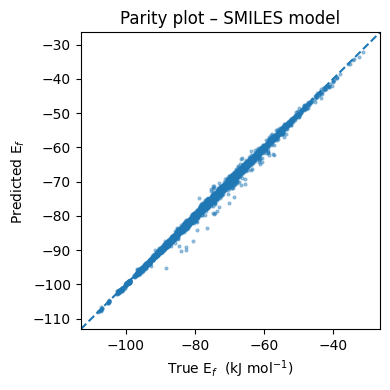

In [25]:
# check full physical range
E_phys = fe * std + mu
print("Dataset range:", E_phys.min(), "→", E_phys.max(), "kJ/mol")

# scatter plot
plt.figure(figsize=(4,4))
plt.scatter(y_t, y_p, s=4, alpha=0.4)
# lims = [y_t.min()-1, y_t.max()+1]
lims = [y_t.min()-5, y_t.max()+5]
plt.plot(lims, lims, '--')         # ideal diagonal
plt.xlabel('True E$_f$  (kJ mol$^{-1}$)')
plt.ylabel('Predicted E$_f$')
plt.title('Parity plot – SMILES model')
plt.xlim(lims); plt.ylim(lims)
plt.tight_layout()
plt.show()

In [27]:
res = y_p - y_t
rare = ('@', '+', '/', '\\')
has_rare = np.array([any(ch in smiles_data[i] for ch in rare) for i in test_idxes])
print("MAE rare vs. non-rare:",
      np.mean(np.abs(res[has_rare])),
      np.mean(np.abs(res[~has_rare])))


MAE rare vs. non-rare: 0.3355149 0.2965525


#### R2 and zoom into extreme errors

R² : 0.997523844242096
ΔE =  -7.31  (true  -82.6)  idx=76312
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.608│     1.244│     0.192
  C  │  6   │    -0.073│    -0.168│    -0.073
  C  │  6   │     0.974│    -0.282│    -1.204
  C  │  6   │     1.735│    -1.507│    -0.979
  N  │  7   │     2.528│    -0.249│    -1.045
  C  │  6   │     3.062│    -0.527│     0.365
  C  │  6   │     1.825│    -1.423│     0.548
  C  │  6   │     0.765│    -0.751│     1.072
  C  │  6   │     0.766│    -0.181│     2.456
  H  │  1   │     0.198│     1.942│     0.440
  H  │  1   │    -1.110│     1.624│    -0.703
  H  │  1   │    -1.335│     1.254│     1.010
  H  │  1   │    -0.924│    -0.795│    -0.382
  H  │  1   │     0.736│     0.076│    -2.203
  H  │  1   │     1.911│    -2.355│    -1.631
  H  │  1   │     4.029│    -1.020│     0.223
  H  │  1   │     3.171│     0.336│     1.030
  H  │  1   │     1.667│    -0.486│     2.996
  H  │  1   │     0

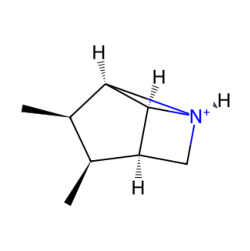

ΔE =  -6.99  (true  -76.6)  idx=71180
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.089│     1.295│     0.346
  C  │  6   │    -0.034│    -0.055│    -0.286
  C  │  6   │    -1.075│    -0.923│    -0.367
  C  │  6   │    -1.596│    -1.550│     0.905
  C  │  6   │    -1.395│    -2.927│     0.436
  C  │  6   │    -0.627│    -2.364│    -0.783
  C  │  6   │     0.628│    -2.268│     0.076
  C  │  6   │     1.244│    -0.892│    -0.316
  N  │  7   │    -0.311│    -2.371│     1.317
  H  │  1   │     0.569│     1.350│     1.223
  H  │  1   │     0.256│     2.075│    -0.347
  H  │  1   │    -1.109│     1.553│     0.645
  H  │  1   │    -2.158│    -1.162│     1.745
  H  │  1   │    -1.910│    -3.858│     0.634
  H  │  1   │    -0.663│    -2.691│    -1.821
  H  │  1   │     1.324│    -3.109│     0.136
  H  │  1   │     1.769│    -1.000│    -1.276
  H  │  1   │     1.967│    -0.475│     0.396


SMILE: C[C@H]1C[C@@H]2[C@@H]3[C@H]1[C@H]

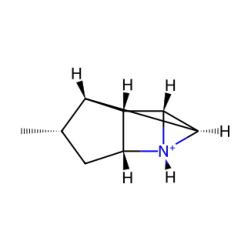

ΔE =  -6.95  (true  -88.3)  idx=71196
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.171│     1.377│    -0.387
  C  │  6   │    -0.060│     0.036│     0.267
  C  │  6   │    -1.094│    -0.819│     0.454
  C  │  6   │    -1.782│    -1.296│    -0.841
  C  │  6   │    -0.733│    -2.455│    -0.718
  C  │  6   │     0.661│    -2.167│    -0.011
  C  │  6   │     1.244│    -0.763│     0.211
  C  │  6   │    -0.600│    -2.251│     0.767
  C  │  6   │    -0.979│    -3.118│     1.929
  H  │  1   │     0.348│     1.402│    -1.355
  H  │  1   │    -1.216│     1.660│    -0.539
  H  │  1   │     0.295│     2.156│     0.231
  H  │  1   │    -2.792│    -1.714│    -0.743
  H  │  1   │    -1.749│    -0.616│    -1.698
  H  │  1   │    -0.839│    -3.415│    -1.220
  H  │  1   │     1.328│    -3.028│    -0.057
  H  │  1   │     1.849│    -0.376│    -0.618
  H  │  1   │     1.891│    -0.750│     1.101
  H  │  1   │    -0.566│    -2.731│     2.

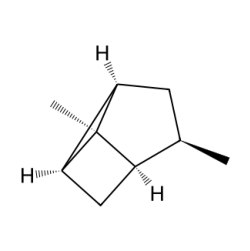

ΔE =  -6.91  (true  -80.5)  idx=76280
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.327│     0.982│     0.747
  C  │  6   │    -0.109│    -0.073│    -0.292
  C  │  6   │    -1.092│    -0.802│    -0.880
  C  │  6   │    -0.512│    -1.999│    -1.647
  C  │  6   │     0.677│    -2.219│    -0.793
  C  │  6   │     1.215│    -0.828│    -0.413
  C  │  6   │    -0.749│    -2.775│    -0.381
  C  │  6   │    -1.876│    -1.773│     0.053
  O  │  8   │    -2.116│    -1.464│     1.387
  H  │  1   │     0.258│     0.798│     1.659
  H  │  1   │    -0.000│     1.962│     0.375
  H  │  1   │    -1.386│     1.071│     1.007
  H  │  1   │    -0.697│    -2.277│    -2.676
  H  │  1   │     1.377│    -3.022│    -1.017
  H  │  1   │     1.933│    -0.483│    -1.171
  H  │  1   │     1.735│    -0.778│     0.553
  H  │  1   │    -0.856│    -3.855│    -0.299
  H  │  1   │    -2.830│    -2.133│    -0.345
  H  │  1   │    -1.279│    -1.209│     1.

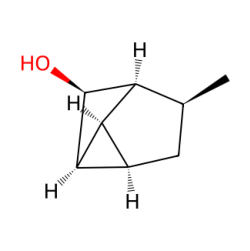

ΔE =  -6.33  (true  -82.6)  idx=71211
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.311│     1.244│    -0.115
  C  │  6   │    -0.319│    -0.112│    -0.058
  C  │  6   │    -0.548│    -0.918│    -1.131
  C  │  6   │     0.746│    -1.271│    -1.898
  C  │  6   │     0.789│    -2.429│    -0.819
  C  │  6   │     0.845│    -2.138│     0.721
  C  │  6   │    -0.646│    -2.376│     0.869
  C  │  6   │    -0.157│    -0.981│     1.123
  C  │  6   │    -0.756│    -2.375│    -0.662
  H  │  1   │     1.326│     1.235│     0.308
  H  │  1   │     0.362│     1.616│    -1.142
  H  │  1   │    -0.264│     1.972│     0.471
  H  │  1   │     0.632│    -1.708│    -2.896
  H  │  1   │     1.533│    -0.513│    -1.916
  H  │  1   │     1.286│    -3.366│    -1.086
  H  │  1   │     1.650│    -2.399│     1.395
  H  │  1   │    -1.196│    -2.969│     1.588
  H  │  1   │    -0.066│    -0.620│     2.143
  H  │  1   │    -1.423│    -3.030│    -1.

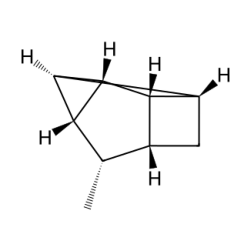

ΔE =  -6.13  (true  -84.0)  idx=71216
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.138│     1.428│    -0.038
  C  │  6   │     0.006│    -0.036│     0.229
  C  │  6   │    -0.978│    -0.914│     0.481
  C  │  6   │    -2.251│    -1.207│    -0.311
  N  │  7   │    -1.523│    -2.417│    -0.872
  C  │  6   │    -0.343│    -2.067│    -1.763
  C  │  6   │     0.702│    -2.154│    -0.585
  C  │  6   │     1.294│    -0.809│    -0.101
  C  │  6   │    -0.542│    -2.351│     0.292
  H  │  1   │     0.441│     2.023│     0.681
  H  │  1   │     0.240│     1.698│    -1.033
  H  │  1   │    -1.181│     1.749│     0.036
  H  │  1   │    -3.115│    -1.565│     0.256
  H  │  1   │    -2.575│    -0.457│    -1.040
  H  │  1   │    -0.217│    -2.839│    -2.525
  H  │  1   │    -0.422│    -1.093│    -2.259
  H  │  1   │     1.420│    -2.971│    -0.682
  H  │  1   │     1.860│    -0.290│    -0.884
  H  │  1   │     1.985│    -0.946│     0.

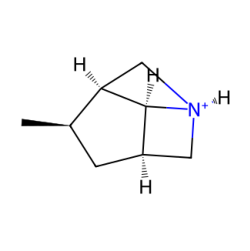

ΔE =  -6.12  (true  -70.2)  idx=71229
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.087│     1.453│    -0.070
  C  │  6   │    -0.034│    -0.014│     0.182
  C  │  6   │    -1.013│    -0.881│     0.507
  C  │  6   │    -2.325│    -1.220│    -0.166
  O  │  8   │    -1.672│    -2.405│    -0.730
  C  │  6   │    -0.553│    -2.277│     0.203
  C  │  6   │     0.912│    -2.100│    -0.271
  O  │  8   │     1.734│    -2.919│    -0.592
  N  │  7   │     1.145│    -0.734│    -0.081
  H  │  1   │     0.557│     2.003│     0.627
  H  │  1   │     0.254│     1.692│    -1.084
  H  │  1   │    -1.106│     1.824│     0.058
  H  │  1   │    -3.150│    -1.518│     0.493
  H  │  1   │    -2.695│    -0.538│    -0.938
  H  │  1   │    -0.594│    -3.066│     0.962
  H  │  1   │     2.056│    -0.328│    -0.231


SMILE: C[C@@H]1NC(=O)[C@@H]2OC[C@H]12


Formation Energy: -70.234
Formation Energy (normalized): 0.57711


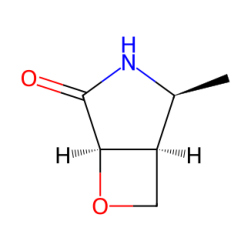

ΔE =  -6.01  (true  -68.6)  idx=23411
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.187│     1.500│    -0.080
  C  │  6   │     1.370│     1.811│     0.096
  C  │  6   │     2.166│     1.942│     1.393
  C  │  6   │     2.723│     0.756│     1.747
  C  │  6   │     2.185│    -0.326│     0.900
  C  │  6   │     1.266│    -1.356│     1.142
  N  │  7   │     0.051│    -1.104│     0.514
  C  │  6   │     0.268│     0.012│    -0.164
  N  │  7   │     1.579│     0.377│    -0.134
  H  │  1   │    -0.786│     1.676│     0.812
  H  │  1   │    -0.663│     1.955│    -0.952
  H  │  1   │     1.770│     2.464│    -0.688
  H  │  1   │     2.382│     2.894│     1.863
  H  │  1   │     3.372│     0.610│     2.601
  H  │  1   │     1.373│    -2.213│     1.791


SMILE: C1=C[C@H]2[CH+][NH2+][C@H]3C[C@@H]1[N@H+]32


Formation Energy: -68.605
Formation Energy (normalized): 0.73504


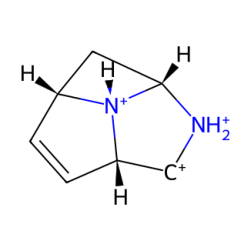

ΔE =  -5.16  (true  -57.1)  idx=126015
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  O  │  8   │    -0.097│     1.318│     0.010
  N  │  7   │     1.090│     2.055│     0.003
  C  │  6   │     2.195│     1.368│    -0.012
  N  │  7   │     2.407│     0.009│    -0.021
  C  │  6   │     1.308│    -0.677│    -0.014
  N  │  7   │     1.149│    -2.029│    -0.020
  C  │  6   │    -0.172│    -2.186│    -0.008
  C  │  6   │    -0.967│    -0.981│     0.007
  C  │  6   │    -0.022│    -0.004│     0.002
  H  │  1   │     3.079│     1.998│    -0.017
  H  │  1   │    -0.593│    -3.187│    -0.009
  H  │  1   │    -2.042│    -0.903│     0.017


SMILE: C1=Nc2[nH]ccc2ON1


Formation Energy: -57.056
Formation Energy (normalized): 1.85511


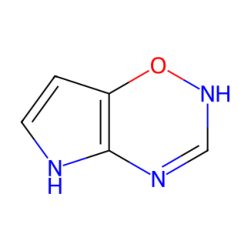

ΔE =  -5.05  (true  -73.6)  idx=23408
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.114│     1.505│    -0.133
  C  │  6   │     1.444│     1.750│     0.048
  C  │  6   │     2.061│     2.286│     1.317
  C  │  6   │     2.128│     1.315│     2.268
  C  │  6   │     1.480│     0.100│     1.760
  C  │  6   │     1.315│     0.304│     0.411
  N  │  7   │     0.014│    -0.046│    -0.025
  C  │  6   │    -0.524│    -0.734│     1.085
  C  │  6   │     0.346│    -0.718│     2.146
  H  │  1   │    -0.696│     1.887│     0.702
  H  │  1   │    -0.521│     1.798│    -1.100
  H  │  1   │     1.934│     2.069│    -0.872
  H  │  1   │     2.530│     3.262│     1.385
  H  │  1   │     2.550│     1.446│     3.257
  H  │  1   │    -1.470│    -1.252│     1.000
  H  │  1   │     0.175│    -1.200│     3.099


SMILE: C1=C[C@@H]2C[N@@H+]3[CH+]C=C1[C@H]23


Formation Energy: -73.633
Formation Energy (normalized): 0.24744


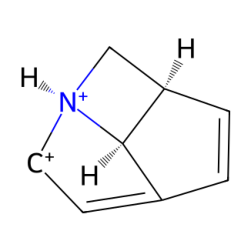

In [28]:
from sklearn.metrics import r2_score

print("R² :", r2_score(y_t, y_p))

# zoom into extreme errors
idx_bad = np.argsort(np.abs(y_p - y_t))[-10:]   # 10 worst
for k in idx_bad[::-1]:
    print(f"ΔE = {y_p[k]-y_t[k]:+6.2f}  (true {y_t[k]:6.1f})  idx={val_dl.dataset.idxs[k]}")
    inspect_structure(val_dl.dataset.idxs[k])


#### Residual Histogram

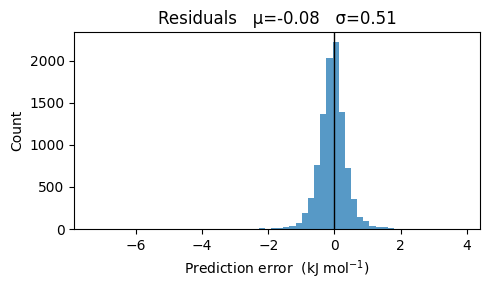

In [29]:
res = y_p - y_t
plt.figure(figsize=(5,3))
plt.hist(res, bins=60, alpha=0.75)
plt.axvline(0, color='k', lw=1)
plt.xlabel('Prediction error  (kJ mol$^{-1}$)')
plt.ylabel('Count')
plt.title(f'Residuals   μ={res.mean():.2f}   σ={res.std():.2f}')
plt.tight_layout(); plt.show()


### Geometric Model

In [30]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn.pool import global_mean_pool


In [31]:
def gaussian_rbf(dist, D_count=20, cutoff=5.0):
    """
    dist : (E,) tensor of pairwise distances  [Å]
    returns (E, D_count) radial-basis embedding
    """
    centers = torch.linspace(0, cutoff, D_count, device=dist.device)
    widths  = (cutoff / D_count)
    return torch.exp(-((dist.unsqueeze(-1) - centers)**2) / widths**2)

def build_radius_graph(pos, cutoff=5.0):
    """
    pos : (N,3)  tensor of Cartesian coordinates
    Returns edge_index [2,E]  and distance vector  (E,)
    """
    dists = torch.cdist(pos, pos)                 # (N,N)
    mask  = (dists < cutoff) & (dists > 0)
    src, dst = torch.nonzero(mask, as_tuple=True)
    edge_index = torch.stack([src, dst], dim=0)        # [2,E]
    # edge_dist  = dists[src, dst]                       # (E,)
    edge_vec = pos[dst] - pos[src]
    return edge_index, edge_vec


In [32]:
class GeometryDataset(torch.utils.data.Dataset):
    def __init__(self, idxs, pos_list, z_list, y_norm, cutoff=5.0, D_count=20):
        self.idxs, self.pos, self.z, self.y = idxs, pos_list, z_list, y_norm
        self.cutoff, self.D_count = cutoff, D_count

    def __getitem__(self, k):
        i = self.idxs[k]
        pos = torch.tensor(self.pos[i], dtype=torch.float32)
        z   = torch.tensor(self.z[i],   dtype=torch.long)

        # Build graph and distances
        edge_index, edge_vec = build_radius_graph(pos, cutoff=self.cutoff)

        # edge features: radial basis of distance magnitudes
        # edge_attr = gaussian_rbf(edge_vec, D_count=self.D_count, cutoff=self.cutoff)

        data = Data(
            z=z,
            pos=pos,
            edge_index=edge_index,
            # edge_attr=edge_attr,
            edge_attr=edge_vec,
            y=torch.tensor([float(self.y[i])])
        )
        return data

    def __len__(self):
        return len(self.idxs)


In [33]:
cutoff = 5.0
train_geo = GeometryDataset(train_idxes, pos_data, type_data, fe)
val_geo   = GeometryDataset(test_idxes,  pos_data, type_data, fe)

train_dl_g = DataLoader(train_geo, batch_size=64, shuffle=True,  num_workers=4)
val_dl_g   = DataLoader(val_geo,   batch_size=64, shuffle=False, num_workers=4)


In [34]:
# from ass2.geom_sources.PaiNN import PaiNN
import sys
import os

# Add the parent directory to Python path so 'ass2' is recognized as a module
sys.path.insert(0, '/content/DeepLearningA2')

# Now the import should work
from ass2.geom_sources.PaiNN import PaiNN

class GeometryNet(nn.Module):
    def __init__(self, emb_dim=128, n_inter=3, cutoff=5.0, D_count=20):
        super().__init__()
        self.atomic_emb = nn.Embedding(100, emb_dim)    # Z → scalar features
        max_nodes = max(len(p) for p in pos_data)
        self.painn = PaiNN(
            num_feat=emb_dim,
            out_channels=emb_dim,
            num_nodes=max_nodes,
            n_rbf=D_count,
            cut_off=cutoff,
            num_interactions=n_inter
        )
        self.head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2), nn.SiLU(),
            nn.Linear(emb_dim//2, 1)
        )

    def forward(self, data):
        s0 = self.atomic_emb(data.z)                    # (N,F)
        v0 = torch.zeros(s0.size(0), s0.size(1), 3,
                         device=s0.device)              # zero vector feats
        s = self.painn(s0, v0, data.edge_index, data.edge_attr)
        g = global_mean_pool(s, data.batch)
        return self.head(g).squeeze(-1)

In [35]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

gmodel = GeometryNet().to(device)
optim_g = torch.optim.AdamW(gmodel.parameters(), lr=3e-4, weight_decay=1e-4)
sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(optim_g, T_max=30)
loss_fn = nn.MSELoss()

def run_epoch_geo(loader, train=True):
    gmodel.train(train)
    loss_sum, n = 0.0, 0
    # Wrap loader with tqdm for a progress bar
    loader_tqdm = tqdm(loader, leave=False, desc="Train" if train else "Val")
    for data in loader_tqdm:
        data = data.to(device)
        with torch.set_grad_enabled(train):
            pred = gmodel(data)
            loss = loss_fn(pred, data.y.view(-1))
            if train:
                optim_g.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(gmodel.parameters(), 1.0)
                optim_g.step()
        loss_sum += loss.item() * data.num_graphs
        n        += data.num_graphs
        # Update progress bar with the current loss
        loader_tqdm.set_postfix(loss=loss_sum/n)
    if train: sched_g.step()
    return loss_sum / n


In [36]:
best = 1e9; patience = 5; stale = 0
for epoch in range(1, 51):
    tr = run_epoch_geo(train_dl_g, True)
    va = run_epoch_geo(val_dl_g,   False)
    if va < best - 1e-4:
        best, stale = va, 0
        torch.save(gmodel.state_dict(), "best_geometry.pt")
    else:
        stale += 1
    if stale >= patience:
        print("No progress for", patience, "epochs → stop")
        break
    print(f"E{epoch:02d}  train {tr:.4f}  val {va:.4f}")


Train:   0%|          | 0/1860 [00:00<?, ?it/s]

Val:   0%|          | 0/157 [00:00<?, ?it/s]

E01  train 0.0626  val 0.0086


Train:   0%|          | 0/1860 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^

...

E17  train 0.0002  val 0.0001


Train:   0%|          | 0/1860 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
^^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^^ ^

Val:   0%|          | 0/157 [00:00<?, ?it/s]

No progress for 5 epochs → stop


In [37]:
std_t = torch.tensor(float(std), device=device)
mu_t  = torch.tensor(float(mu),  device=device)

def collect_geo(loader):
    gmodel.eval(); y_t, y_p = [], []
    with torch.no_grad():
        for d in loader:
            d = d.to(device)
            y_hat = gmodel(d)
            y_t.append((d.y.view(-1)*std_t + mu_t).cpu())
            y_p.append((y_hat       *std_t + mu_t).cpu())
    return torch.cat(y_t).numpy(), torch.cat(y_p).numpy()

y_true, y_pred = collect_geo(val_dl_g)

mae  = mean_absolute_error(y_true, y_pred)
# mse  = mean_squared_error(y_true, y_pred)
# rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

print("MAE :", mean_absolute_error(y_true, y_pred))
# print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))
print("R²  :", r2_score(y_true, y_pred))


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0><function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()    Exception ignored in: 
self._shutdown_workers()  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers

  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b9f1c58dee0>    Exception ignored in: 
if w.is_alive():    
Traceback (most recent call last):
if w.is_alive():   File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/datalo

MAE : 0.1065385714173317
R²  : 0.99983149766922


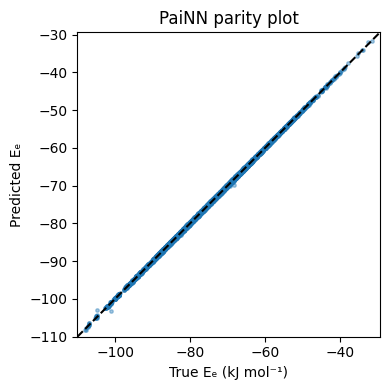

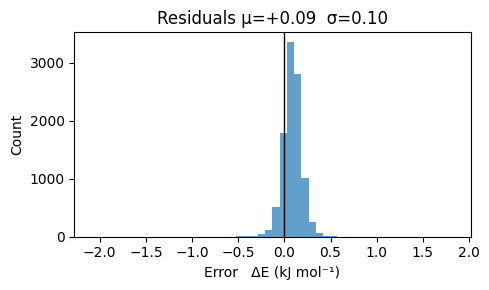

ΔE =  -2.08   True -101.1   idx=6168
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.120│     1.530│     0.196
  C  │  6   │     0.047│     0.015│     0.035
  C  │  6   │     0.770│    -0.430│    -1.253
  C  │  6   │     2.225│     0.059│    -1.289
  C  │  6   │     0.672│    -1.962│    -1.394
  C  │  6   │     1.222│    -2.592│    -2.689
  C  │  6   │     1.145│    -4.123│    -2.602
  C  │  6   │     0.493│    -2.088│    -3.943
  H  │  1   │     0.840│     2.044│     0.294
  H  │  1   │    -0.642│     1.963│    -0.665
  H  │  1   │    -0.707│     1.765│     1.090
  H  │  1   │     0.586│    -0.389│     0.904
  H  │  1   │    -0.946│    -0.452│     0.054
  H  │  1   │     0.236│     0.031│    -2.097
  H  │  1   │     2.804│    -0.385│    -0.469
  H  │  1   │     2.720│    -0.209│    -2.226
  H  │  1   │     2.289│     1.146│    -1.190
  H  │  1   │     1.189│    -2.419│    -0.538
  H  │  1   │    -0.384│    -2.254│    -1.2

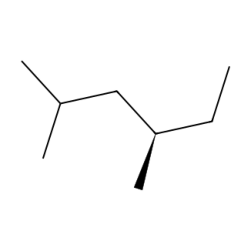

ΔE =  +1.82   True -104.8   idx=97419
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     1.082│     1.452│     2.441
  O  │  8   │     1.513│     0.362│     1.663
  C  │  6   │     0.482│    -0.529│     1.244
  C  │  6   │    -0.396│     0.086│     0.147
  C  │  6   │     1.173│    -1.847│     0.823
  C  │  6   │     2.185│    -1.596│    -0.308
  C  │  6   │     1.804│    -2.568│     2.048
  C  │  6   │     0.737│    -3.082│     3.029
  C  │  6   │     2.715│    -3.740│     1.649
  H  │  1   │     0.493│     1.123│     3.312
  H  │  1   │     1.977│     1.967│     2.799
  H  │  1   │     0.475│     2.170│     1.870
  H  │  1   │    -0.170│    -0.735│     2.107
  H  │  1   │     0.204│     0.419│    -0.705
  H  │  1   │    -1.128│    -0.646│    -0.209
  H  │  1   │    -0.952│     0.949│     0.524
  H  │  1   │     0.378│    -2.499│     0.430
  H  │  1   │     2.577│    -2.534│    -0.707
  H  │  1   │     1.724│    -1.062│    -1.

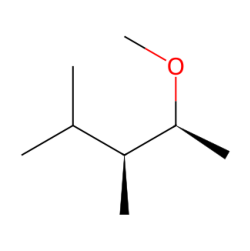

ΔE =  -1.38   True  -68.4   idx=52509
Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  N  │  7   │     0.025│     1.321│     0.072
  C  │  6   │    -0.056│    -0.045│    -0.004
  N  │  7   │     1.148│    -0.726│    -0.070
  H  │  1   │     1.937│    -0.167│    -0.361
  H  │  1   │     1.107│    -1.589│    -0.594
  C  │  6   │    -1.281│    -0.685│    -0.012
  C  │  6   │    -2.593│    -0.186│    -0.096
  C  │  6   │    -3.542│    -1.276│    -0.052
  O  │  8   │    -4.779│    -1.285│    -0.114
  C  │  6   │    -2.665│    -2.439│     0.088
  H  │  1   │    -2.953│    -3.472│     0.229
  N  │  7   │    -1.361│    -2.087│     0.049
  H  │  1   │     0.882│     1.707│     0.439
  H  │  1   │    -0.803│     1.773│     0.436
  H  │  1   │    -2.860│     0.843│    -0.291
  H  │  1   │    -0.638│    -2.651│     0.472


SMILE: NC(=[NH2+])c1cc(O)c[nH]1


Formation Energy: -68.406
Formation Energy (normalized): 0.75437


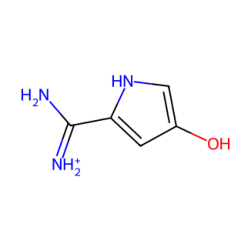

In [38]:
# ── parity plot ───────────────────────────────────────────────
plt.figure(figsize=(4,4))
plt.scatter(y_true, y_pred, s=6, alpha=0.4)
lims = [y_true.min()-2, y_true.max()+2]
plt.plot(lims, lims, '--k')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('True Eₑ (kJ mol⁻¹)')
plt.ylabel('Predicted Eₑ')
plt.title('PaiNN parity plot')
plt.tight_layout(); plt.show()

# ── residual histogram ───────────────────────────────────────
res = y_pred - y_true
plt.figure(figsize=(5,3))
plt.hist(res, bins=50, alpha=0.7)
plt.axvline(0,color='k',lw=1)
plt.xlabel('Error   ΔE (kJ mol⁻¹)')
plt.ylabel('Count')
plt.title(f'Residuals μ={res.mean():+.2f}  σ={res.std():.2f}')
plt.tight_layout(); plt.show()

# ── inspect worst 3 molecules ────────────────────────────────
worst = np.argsort(np.abs(res))[-3:][::-1]
for k in worst:
    print(f"ΔE = {res[k]:+6.2f}   True {y_true[k]:6.1f}   idx={val_dl_g.dataset.idxs[k]}")
    inspect_structure(val_dl_g.dataset.idxs[k])


## Task 2

In [39]:
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
import pandas as pd

      Epoch 0: train=1.1600, val=0.9396
      Epoch 10: train=0.5416, val=0.6265
      Epoch 20: train=0.3188, val=0.4669
      Epoch 30: train=0.2920, val=0.4403
      Epoch 40: train=0.2760, val=0.4155
SMILES Results: Spearman=0.8516, R2=0.7063
      Early stop at epoch 15
 Geometry Results: Spearman=0.8763, R²=0.5883
      Epoch 0: train=0.9774, val=0.9174
      Epoch 10: train=0.3618, val=0.3802
      Epoch 20: train=0.2038, val=0.2594
      Epoch 30: train=0.1792, val=0.2429
      Epoch 40: train=0.1583, val=0.2172
SMILES Results: Spearman=0.9151, R2=0.8426
      Early stop at epoch 31
 Geometry Results: Spearman=0.9143, R²=0.8208
      Epoch 0: train=0.9158, val=0.7655
      Epoch 10: train=0.1516, val=0.1948
      Epoch 20: train=0.0889, val=0.1184
      Epoch 30: train=0.0791, val=0.1072
      Early stop at epoch 33
SMILES Results: Spearman=0.9493, R2=0.9017
 Geometry Results: Spearman=0.9638, R²=0.9130
      Epoch 0: train=0.7152, val=0.5795
      Epoch 10: train=0.0553, val=0

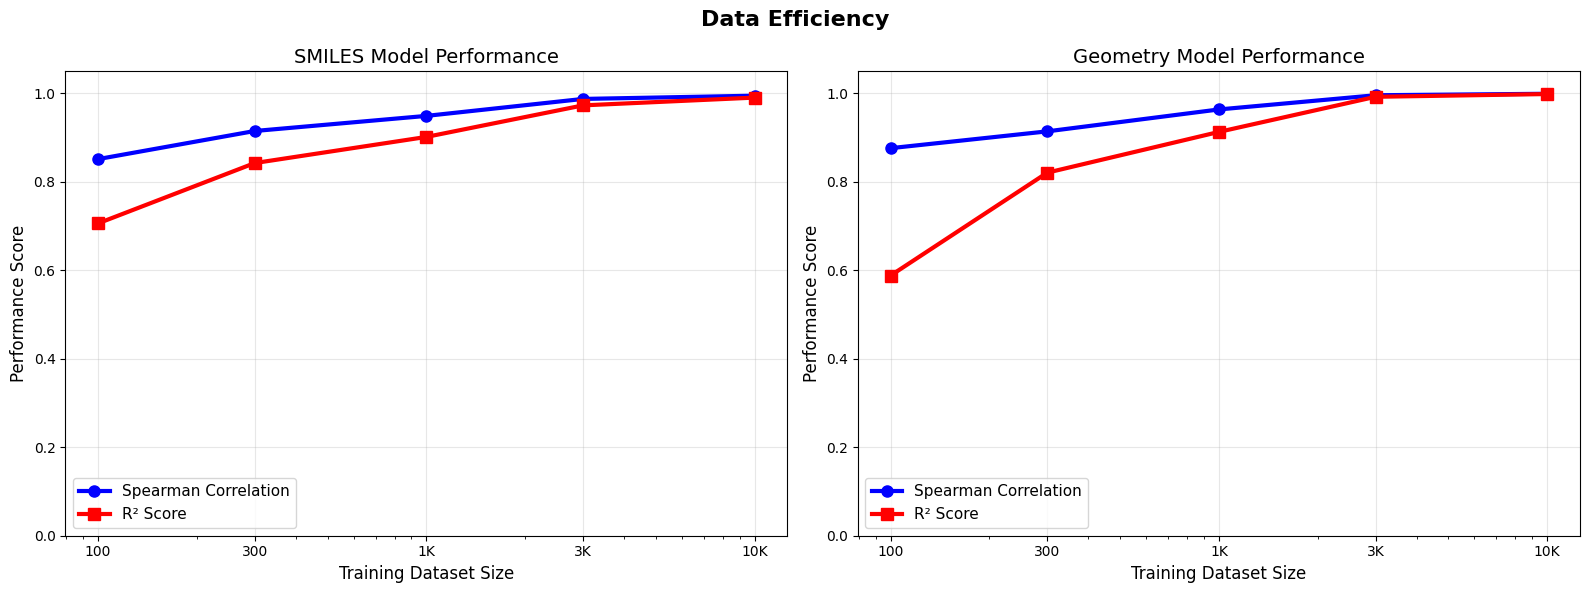

In [40]:
std_float = float(std)
mu_float = float(mu)
subset_sizes = [100, 300, 1000, 3000, 10000]
results = []

for size in subset_sizes:
    np.random.seed(42)
    if size >= len(train_idxes):
        subset_idxs = train_idxes
    else:
        subset_idxs = np.random.choice(train_idxes, size=size, replace=False)


    # SMILES dataset
    train_ds_subset = SMILESDataset( subset_idxs, smiles_data, fe, train=True, augmenter=augmenter)

    # Use working manual batching (keeps same data, just different loading)
    def create_manual_batches(dataset, batch_size=32):
        batches = []
        for i in range(0, len(dataset), batch_size):
            batch_items = [dataset[j] for j in range(i, min(i + batch_size, len(dataset)))]

            sequences, energies = zip(*batch_items)
            max_len = max(len(seq) for seq in sequences)
            padded_seqs = []
            lengths = []

            for seq in sequences:
                padded_seq = seq + [PAD_ID] * (max_len - len(seq))
                padded_seqs.append(torch.tensor(padded_seq, dtype=torch.long))
                lengths.append(len(seq))

            x = torch.stack(padded_seqs)
            l = torch.tensor(lengths, dtype=torch.long)
            y = torch.tensor(energies, dtype=torch.float32)

            batches.append((x, l, y))

        return batches

    batch_size = min(256, len(subset_idxs))
    train_batches = create_manual_batches(train_ds_subset, batch_size)

    # SMILES model
    smiles_model = SmilesGRU(len(tokenizer.vocabulary)).to(device)
    optim_smiles = torch.optim.AdamW(smiles_model.parameters(), lr=2e-4, weight_decay=1e-4)
    sched_smiles = torch.optim.lr_scheduler.CosineAnnealingLR(optim_smiles, T_max=30)
    loss_fn = nn.MSELoss()

    def run_epoch_smiles(batches, train=True):
        smiles_model.train(train)
        total, n = 0.0, 0
        for x, l, y in batches:
            x, l, y = x.to(device), l.to(device), y.to(device)
            with torch.set_grad_enabled(train):
                y_hat = smiles_model(x, l)
                loss = loss_fn(y_hat, y)
                if train:
                    optim_smiles.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(smiles_model.parameters(), 1.0)
                    optim_smiles.step()
                total += loss.item() * len(y)
                n += len(y)
        if train:
            sched_smiles.step()
        return total / n

    best = 1e9
    patience = 5
    stale = 0

    for epoch in range(50):
        tr_loss = run_epoch_smiles(train_batches, True)  # Use manual batches

        # Check progress
        val_loss = 0
        val_count = 0
        smiles_model.eval()
        with torch.no_grad():
            for i, (x, l, y) in enumerate(val_dl):
                if i >= 5:
                    break
                x, l, y = x.to(device), l.to(device), y.to(device)
                y_hat = smiles_model(x, l)
                val_loss += loss_fn(y_hat, y).item()
                val_count += 1

        avg_val_loss = val_loss / max(val_count, 1)

        if avg_val_loss < best - 1e-4:
            best, stale = avg_val_loss, 0
        else:
            stale += 1
            if stale >= patience:
                print(f"      Early stop at epoch {epoch}")
                break

        if epoch % 10 == 0:
            print(f"      Epoch {epoch}: train={tr_loss:.4f}, val={avg_val_loss:.4f}")

    # Evaluate SMILES model
    smiles_model.eval()
    y_true_smiles, y_pred_smiles = [], []

    with torch.no_grad():
        for x, l, y_norm in val_dl:
            x, l, y_norm = x.to(device), l.to(device), y_norm.to(device)
            y_pred_norm = smiles_model(x, l)

            y_pred_norm_cpu = y_pred_norm.cpu()
            y_norm_cpu = y_norm.cpu()

            y_pred = (y_pred_norm_cpu * std_float + mu_float).numpy()
            y_true = (y_norm_cpu * std_float + mu_float).numpy()

            y_true_smiles.extend(y_true)
            y_pred_smiles.extend(y_pred)

    spearman_smiles, _ = spearmanr(y_true_smiles, y_pred_smiles)
    r2_smiles = r2_score(y_true_smiles, y_pred_smiles)

    print(f"SMILES Results: Spearman={spearman_smiles:.4f}, R2={r2_smiles:.4f}")

    results.append({
        'subset_size': size,
        'model_type': 'SMILES',
        'spearman_correlation': spearman_smiles,
        'r2_score': r2_smiles
    })

    # Geometry model
    geo_ds_subset = GeometryDataset(subset_idxs, pos_data, type_data, fe)
    geo_dl_subset = DataLoader(geo_ds_subset, batch_size=min(64, len(subset_idxs)), shuffle=True, num_workers=4)
    geo_model = GeometryNet().to(device)
    optim_geo = torch.optim.AdamW(geo_model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched_geo = torch.optim.lr_scheduler.CosineAnnealingLR(optim_geo, T_max=30)

    def run_epoch_geo(loader, train=True):
        geo_model.train(train)
        loss_sum, n = 0.0, 0
        for data in loader:
            data = data.to(device)
            with torch.set_grad_enabled(train):
                pred = geo_model(data)
                loss = loss_fn(pred, data.y.view(-1))
                if train:
                    optim_geo.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(geo_model.parameters(), 1.0)
                    optim_geo.step()
                loss_sum += loss.item() * data.num_graphs
                n += data.num_graphs
        if train:
            sched_geo.step()
        return loss_sum / n

    best = 1e9
    patience = 5
    stale = 0

    for epoch in range(51):
        tr_loss = run_epoch_geo(geo_dl_subset, True)

        # Check
        val_loss = 0
        val_count = 0
        geo_model.eval()
        with torch.no_grad():
            for i, data in enumerate(val_dl_g):
                if i >= 5:
                    break
                data = data.to(device)
                pred = geo_model(data)
                val_loss += loss_fn(pred, data.y.view(-1)).item()
                val_count += 1

        avg_val_loss = val_loss / max(val_count, 1)

        if avg_val_loss < best - 1e-4:
            best, stale = avg_val_loss, 0
        else:
            stale += 1
            if stale >= patience:
                print(f"      Early stop at epoch {epoch}")
                break

    # Evaluate Geometry model
    geo_model.eval()
    y_true_geo, y_pred_geo = [], []

    with torch.no_grad():
        for data in val_dl_g:
            data = data.to(device)
            y_pred_norm = geo_model(data)

            y_pred_norm_cpu = y_pred_norm.cpu()
            y_norm_cpu = data.y.view(-1).cpu()

            y_pred = (y_pred_norm_cpu * std_float + mu_float).numpy()
            y_true = (y_norm_cpu * std_float + mu_float).numpy()

            y_true_geo.extend(y_true)
            y_pred_geo.extend(y_pred)

    spearman_geo, _ = spearmanr(y_true_geo, y_pred_geo)
    r2_geo = r2_score(y_true_geo, y_pred_geo)

    print(f" Geometry Results: Spearman={spearman_geo:.4f}, R²={r2_geo:.4f}")

    results.append({
        'subset_size': size,
        'model_type': 'Geometry',
        'spearman_correlation': spearman_geo,
        'r2_score': r2_geo
    })

    # Cleanup
    del smiles_model, geo_model
    torch.cuda.empty_cache()



print(f"Final dataset:")
results_df = pd.DataFrame(results)
print(results_df)

pivot_spearman = results_df.pivot(index='subset_size', columns='model_type', values='spearman_correlation')
pivot_r2 = results_df.pivot(index='subset_size', columns='model_type', values='r2_score')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Efficiency', fontsize=16, fontweight='bold')

# SMILES Model Plot
ax1.plot(pivot_spearman.index, pivot_spearman['SMILES'], 'o-',
         color='blue', linewidth=3, markersize=8, label='Spearman Correlation')
ax1.plot(pivot_r2.index, pivot_r2['SMILES'], 's-',
         color='red', linewidth=3, markersize=8, label='R² Score')

ax1.set_xlabel('Training Dataset Size', fontsize=12)
ax1.set_ylabel('Performance Score', fontsize=12)
ax1.set_title('SMILES Model Performance', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_xticks(subset_sizes)
ax1.set_xticklabels(['100', '300', '1K', '3K', '10K'])
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)

# Geometry Model Plot
ax2.plot(pivot_spearman.index, pivot_spearman['Geometry'], 'o-',
         color='blue', linewidth=3, markersize=8, label='Spearman Correlation')
ax2.plot(pivot_r2.index, pivot_r2['Geometry'], 's-',
         color='red', linewidth=3, markersize=8, label='R² Score')

ax2.set_xlabel('Training Dataset Size', fontsize=12)
ax2.set_ylabel('Performance Score', fontsize=12)
ax2.set_title('Geometry Model Performance', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_xticks(subset_sizes)
ax2.set_xticklabels(['100', '300', '1K', '3K', '10K'])
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Task 3

### GRU Model

In [48]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class GRU(nn.Module):
    def __init__(self, vocab_size, hidden_size=256, num_layers=3, dropout=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Layers
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x, hidden=None):
        batch_size, seq_len = x.size()

        # Embedding
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        # GRU and outputs
        output, hidden = self.gru(embedded, hidden)
        logits = self.output(output)

        return logits, hidden

    def generate(self, start_token=None, max_length=80, temperature=1.0, device='cuda'):
        if start_token is None:
            start_token = BOS_ID # add the start token

        self.eval()
        with torch.no_grad():
            generated = [start_token]
            hidden = None

            # Generate token by token
            for step in range(max_length):
                current_input = torch.tensor([[generated[-1]]], device=device)

                logits, hidden = self.forward(current_input, hidden)  # forward pass
                next_logits = logits[0, 0, :] / temperature  # next token

                if step > 0: # stop BOS from being generated again
                    next_logits[BOS_ID] = -float('inf')

                probs = F.softmax(next_logits, dim=0) # sample the token
                next_token = torch.multinomial(probs, 1).item()
                generated.append(next_token)
                if next_token == EOS_ID: # add the end token
                    break

            return generated

### Dataset

In [49]:
class GRULanguageDataset(Dataset):
    def __init__(self, smiles_list, tokenizer, max_length=80):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.sequences = []

        for smiles in tqdm(smiles_list):
            tokens = tokenizer(smiles) # tokenization
            token_ids = [BOS_ID]

            # Convert tokens to IDs
            for token_tensor in tokens:
                if isinstance(token_tensor, torch.Tensor):
                    token_ids.extend(token_tensor.tolist())

            token_ids.append(EOS_ID)
            self.sequences.append(token_ids)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # For language modeling: predict next token
        input_seq = seq[:-1]  # exclude BOS
        target_seq = seq[1:]  # exclude EOS

        # Pad to same length
        max_len = self.max_length - 1
        input_len = len(input_seq)

        # Pad sequences
        input_padded = input_seq + [PAD_ID] * (max_len - len(input_seq))
        target_padded = target_seq + [PAD_ID] * (max_len - len(target_seq))

        # Truncate if too long
        input_padded = input_padded[:max_len]
        target_padded = target_padded[:max_len]

        return {
            'input': torch.tensor(input_padded, dtype=torch.long),
            'target': torch.tensor(target_padded, dtype=torch.long),
            'length': min(input_len, max_len)
        }

### Train function

In [50]:
def train_gru(model, dataloader, epochs=30, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    model.train()
    train_losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0

        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in progress_bar:
            input_ids = batch['input'].to(device)  # [batch_size, seq_len]
            target_ids = batch['target'].to(device)  # [batch_size, seq_len]

            optimizer.zero_grad()

            logits, _ = model(input_ids) #forward
            loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1)) #loss function
            loss.backward() #bakcward
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) #gradient

            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'}) #upgrade progress bar

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

    return train_losses

In [51]:
# Create dataset
train_smiles = [smiles_data[i] for i in train_idxes]
gru_dataset = GRULanguageDataset(train_smiles, tokenizer, max_length=80)

# Create dataloader
gru_dataloader = DataLoader(gru_dataset, batch_size=64, shuffle=True, num_workers=0)

vocab_size = len(tokenizer.vocabulary)
gru_model = GRU(vocab_size=vocab_size, hidden_size=256, num_layers=3, dropout=0.2)

# Train the model
gru_train = train_gru(gru_model, gru_dataloader, epochs=10, lr=1e-3)

  0%|          | 0/119012 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/1860 [00:00<?, ?it/s]

Epoch 1/10, Average Loss: 0.6884


Epoch 2/10:   0%|          | 0/1860 [00:00<?, ?it/s]

Epoch 2/10, Average Loss: 0.5584


...

Epoch 8/10, Average Loss: 0.5106


Epoch 9/10:   0%|          | 0/1860 [00:00<?, ?it/s]

Epoch 9/10, Average Loss: 0.5090


Epoch 10/10:   0%|          | 0/1860 [00:00<?, ?it/s]

Epoch 10/10, Average Loss: 0.5074


### Evaluation function

In [52]:
def evaluate_generation(generated_smiles, training_smiles_set):
    # Validity
    valid = [s for s in generated_smiles if s and is_valid_smiles(s)]
    validity = len(valid) / len(generated_smiles) * 100

    # Uniqueness
    canonical = {canonicalize(s) for s in valid if canonicalize(s) != 'None'}
    uniqueness = len(canonical) / len(valid) * 100 if valid else 0

    # Novelty
    train_canonical = {canonicalize(s) for s in training_smiles_set if canonicalize(s) != 'None'}
    novel = canonical - train_canonical
    novelty = len(novel) / len(canonical) * 100 if canonical else 0

    return validity, uniqueness, novelty

def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

### Generate 5000 molecules function

In [55]:
def tokens_to_smiles_simple(token_ids, tokenizer):
    # create reverse mapping
    id_to_char = {id_val: char for char, id_val in tokenizer.vocabulary.items()}

    smiles_str = ""
    for token_id in token_ids:
        if token_id in [BOS_ID, EOS_ID, PAD_ID, UNK_ID]: # skip these tokens
            continue

        # get character
        if token_id in id_to_char:
            char = id_to_char[token_id]
            if char not in [' ', '^', '&', '?']: # skip the chars of the tokens
                smiles_str += char

    return smiles_str

def generate_batches(model, n_molecules=5000, temperature=1.1, device='cuda'):
    model.eval()
    model.to(device)
    generated_smiles = []

    for i in tqdm(range(n_molecules)):
      token_sequence = model.generate(start_token=BOS_ID, max_length=80, temperature=temperature, device=device )
      smiles_str = tokens_to_smiles_simple(token_sequence, tokenizer)
      generated_smiles.append(smiles_str)

    return generated_smiles


# Generate molecules
temperature = 1
n_molecules = 5000
generated_smiles = generate_batches(gru_model, n_molecules=n_molecules, temperature=temperature, device=device)

# Evaluation and metrics
training_smiles_set = set(train_smiles)
validity, uniqueness, novelty = evaluate_generation(generated_smiles, training_smiles_set)
print(f"Validity:   {validity:.2f}%")
print(f"Uniqueness: {uniqueness:.2f}%")
print(f"Novelty:    {novelty:.2f}%")

  0%|          | 0/5000 [00:00<?, ?it/s]

Validity:   95.12%
Uniqueness: 98.28%
Novelty:    43.62%
